<a href="https://colab.research.google.com/github/Breezlyx/MineriaDeDatos-Entrega1/blob/main/Entrega_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Estudios/Mineria de Datos/job_salary_prediction_dataset.csv")

In [ ]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [ ]:
df.tail()  #visualizamos las ultimas 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(250000, 10)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64
salary,int64


In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


# Limpieza de nulos
Como podemos observar, en nuestro dataset no hay presencia de valores nulos, por lo que no será necesario aplicar técnicas de limpieza en esta fase.

In [ ]:
df.columns #mostramos los nombres de las columnas

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary', 'education_encoded', 'company_encoded'],
      dtype='object')

# Mapeo de datos
job_title:	El rol o posición de trabajo (ej: Data Analyst, AI Engineer)(Numerica Discreta)

experience_years:	Numero de años de experiencia profesional. (Numerica Discreta)

education_level:	Nivel más alto de educación completado. (Categorica Ordinal)

skills_count:	Número de habilidads técnicas o profesionales.(Numerica Discreta)

industry:	Sector de la industria donde pertnece el trabajo. (Categorica Nominal)

company_size:	Tamaño de la compañía (small, medium, large) (Categorica Nominal)

location	Job: Localización o región (Categorica Nominal)

remote_work:	Si es que el trabajo permite trabajo remoto. (Categorica Nominal)

certifications:	Número de certificaciones profesionales (Numerica Discreta)

salary:	Salario anual de empleados (USD) (Numerica Discreta)

In [ ]:
df['location'].value_counts().count()

np.int64(10)

In [ ]:
df['job_title'].value_counts().count()

np.int64(12)

In [ ]:
df['industry'].value_counts().count()

np.int64(10)

In [ ]:
df['education_level'].value_counts().count()

np.int64(5)

In [ ]:
df['company_size'].value_counts().count()

np.int64(5)

Se realiza un encoding ordinal para las columnas education_level y company_size

In [ ]:
# Definimos el diccionario con la jerarquía (de menor a mayor)
education_map = {
    'High School': 1,
    'Diploma': 2,
    'Bachelor': 3,
    'Master': 4,
    'PhD': 5
}

company_map = {
    'Startup': 1,
    'Small': 2,
    'Medium': 3,
    'Large': 4,
    'Enterprise': 5
}

# Aplicamos el mapeo creando nuevas columnas
df['education_encoded'] = df['education_level'].map(education_map)
df['company_encoded'] = df['company_size'].map(company_map)

# Verificamos los cambios
df[['education_level', 'education_encoded', 'company_size', 'company_encoded']].head()

,education_level,education_encoded,company_size,company_encoded
0,Bachelor,3,Medium,3
1,Bachelor,3,Small,2
2,PhD,5,Medium,3
3,PhD,5,Medium,3
4,Bachelor,3,Large,4


Aplicamos One Hot Encoding para la columna remote_work

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Instanciamos el codificador siguiendo la diapositiva 73
ohc = OneHotEncoder()

# Ajustamos y transformamos la columna 'industry' desde df_encoded
ohe = ohc.fit_transform(df_encoded[['industry']]).toarray()

# Creamos el DataFrame de categorías con la lógica de nombres del material
df_industry_ohe = pd.DataFrame(ohe, columns = ["industry_"+str(ohc.categories_[0][i])
                                               for i in range(len(ohc.categories_[0]))])

# Concatenamos las nuevas columnas a df_encoded para conservar el progreso
df_encoded = pd.concat([df_encoded, df_industry_ohe], axis=1)

# Visualizamos el avance
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,...,industry_Consulting,industry_Education,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Aplicamos One Hot Encoding para la columna industry

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Instanciamos el codificador para variables nominales
ohc = OneHotEncoder()

# Ajustamos y transformamos la columna 'industry'
ohe = ohc.fit_transform(df[['industry']]).toarray()

# Creamos un nuevo DataFrame con las columnas generadas
df_industry_ohe = pd.DataFrame(ohe, columns=ohc.get_feature_names_out(['industry']))

# Concatenamos las nuevas columnas al DataFrame de trabajo 'df_encoded'
# Nota: Si ya habías creado df_encoded en el paso de Ordinal Encoding,
# asegúrate de concatenar sobre esa misma variable para no perder los cambios.
df_encoded = pd.concat([df, df_industry_ohe], axis=1)

# Visualizamos el progreso
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,...,industry_Consulting,industry_Education,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Aplicamos Binary Encoder para las columnas job_title y location

In [ ]:
import category_encoders as ce

# Instanciamos el codificador para las columnas con alta cardinalidad
encoder = ce.BinaryEncoder(cols=['job_title', 'location'])

# Generamos las nuevas columnas binarias (esto reduce la dimensionalidad frente al One-Hot)
df_bin_cols = encoder.fit_transform(df_encoded[['job_title', 'location']])

# Concatenamos las nuevas columnas al DataFrame actual
df_encoded = pd.concat([df_encoded, df_bin_cols], axis=1)

# Visualizamos el progreso
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,...,industry_Technology,industry_Telecom,job_title_0,job_title_1,job_title_2,job_title_3,location_0,location_1,location_2,location_3
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,...,0.0,0.0,0,0,0,1,0,0,0,1
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,...,0.0,1.0,0,0,1,0,0,0,1,0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,...,0.0,0.0,0,0,1,1,0,0,1,1
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,...,0.0,0.0,0,1,0,0,0,1,0,0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,...,0.0,0.0,0,1,0,1,0,1,0,1


In [ ]:
df_encoded.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary', 'education_encoded', 'company_encoded', 'remote_work_Hybrid',
       'remote_work_No', 'remote_work_Yes', 'industry_Consulting',
       'industry_Education', 'industry_Finance', 'industry_Government',
       'industry_Healthcare', 'industry_Manufacturing', 'industry_Media',
       'industry_Retail', 'industry_Technology', 'industry_Telecom',
       'job_title_0', 'job_title_1', 'job_title_2', 'job_title_3',
       'location_0', 'location_1', 'location_2', 'location_3'],
      dtype='object')

# Mapa de correlación

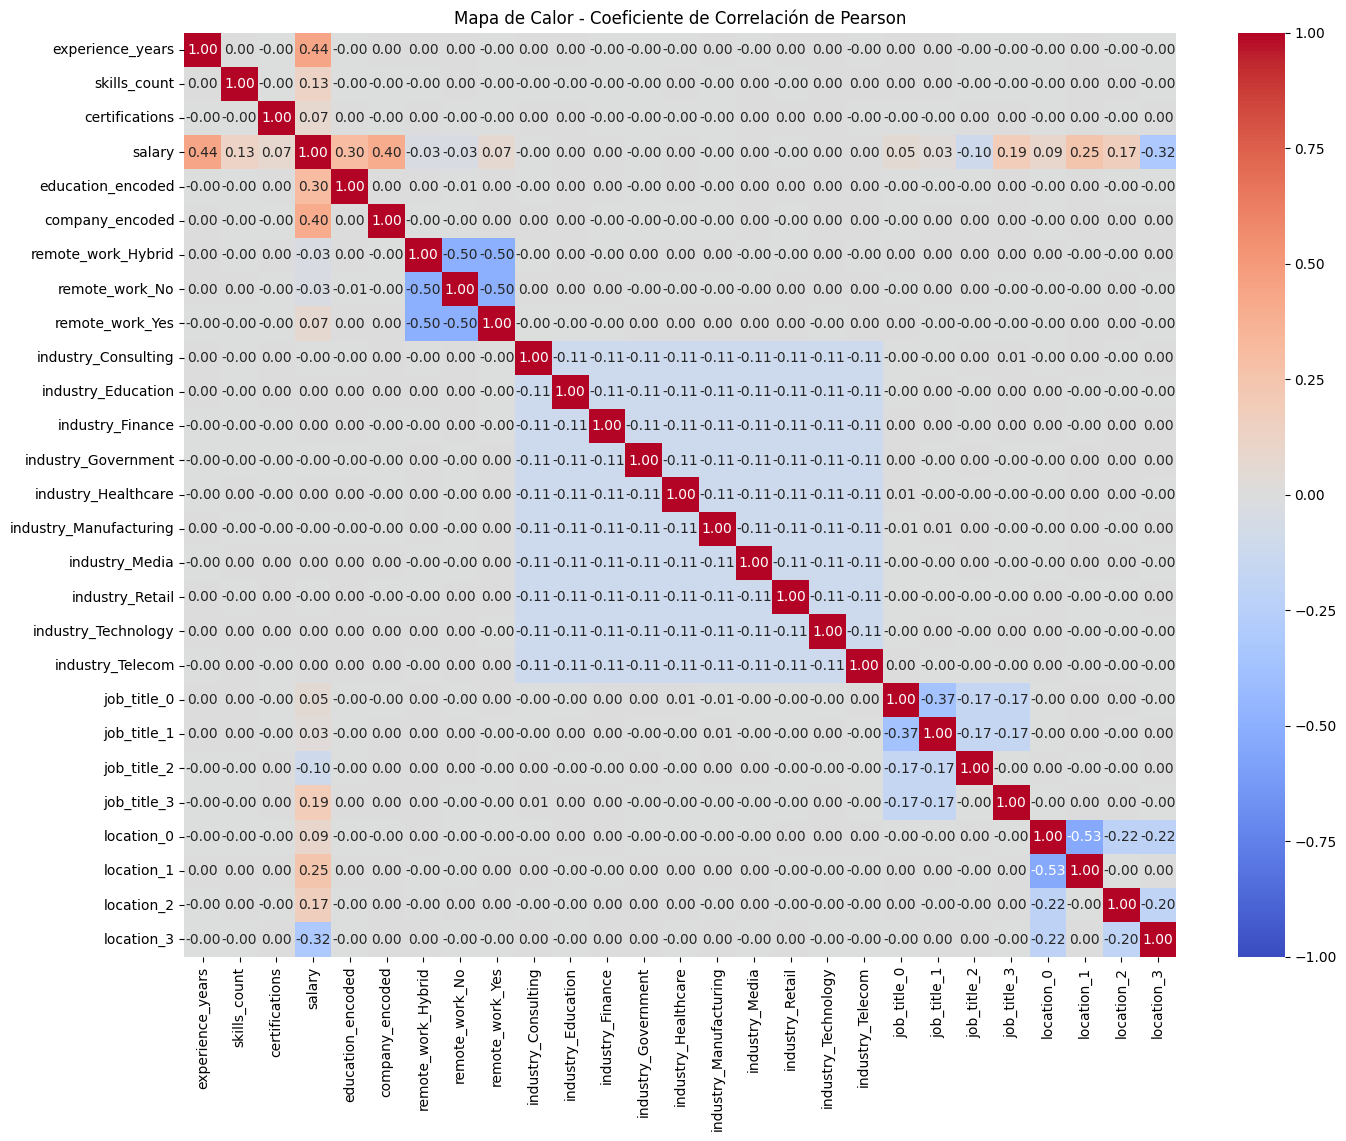

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos para mantener exclusivamente columnas numéricas
# Esto previene errores al intentar calcular correlaciones sobre texto
df_numeric = df_encoded.select_dtypes(include=['number'])

# Calculamos la matriz de correlación de Pearson (método por defecto en pandas)
matriz_correlacion = df_numeric.corr()

# Configuramos el tamaño del gráfico para que se lea bien (son bastantes columnas)
plt.figure(figsize=(16, 12))

# Generamos el mapa de calor con los parámetros del PPT
sns.heatmap(matriz_correlacion, vmin=-1, vmax=+1, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Mapa de Calor - Coeficiente de Correlación de Pearson")
plt.show()